In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

%matplotlib inline
plt.style.use('fivethirtyeight')
sns.set_style('whitegrid')

In [2]:
df = pd.read_csv('all_stocks_5yr.csv')
df['date'] = pd.to_datetime(df['date'])

print("Thông tin bộ dữ liệu:")
print(df.info())
print("\nSố lượng mã cổ phiếu độc nhất:", df['Name'].nunique())
df.head()

Thông tin bộ dữ liệu:
<class 'pandas.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    619040 non-null  datetime64[us]
 1   open    619029 non-null  float64       
 2   high    619032 non-null  float64       
 3   low     619032 non-null  float64       
 4   close   619040 non-null  float64       
 5   volume  619040 non-null  int64         
 6   Name    619040 non-null  str           
dtypes: datetime64[us](1), float64(4), int64(1), str(1)
memory usage: 34.9 MB
None

Số lượng mã cổ phiếu độc nhất: 505


,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


In [3]:
ticker = 'AAL'
stock_df = df[df['Name'] == ticker].sort_values('date').copy()
stock_df.set_index('date', inplace=True)

print(f"Tổng số ngày giao dịch của mã {ticker}: {len(stock_df)}")
stock_df.head()

Tổng số ngày giao dịch của mã AAL: 1259


,open,high,low,close,volume,Name
date,,,,,,
2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


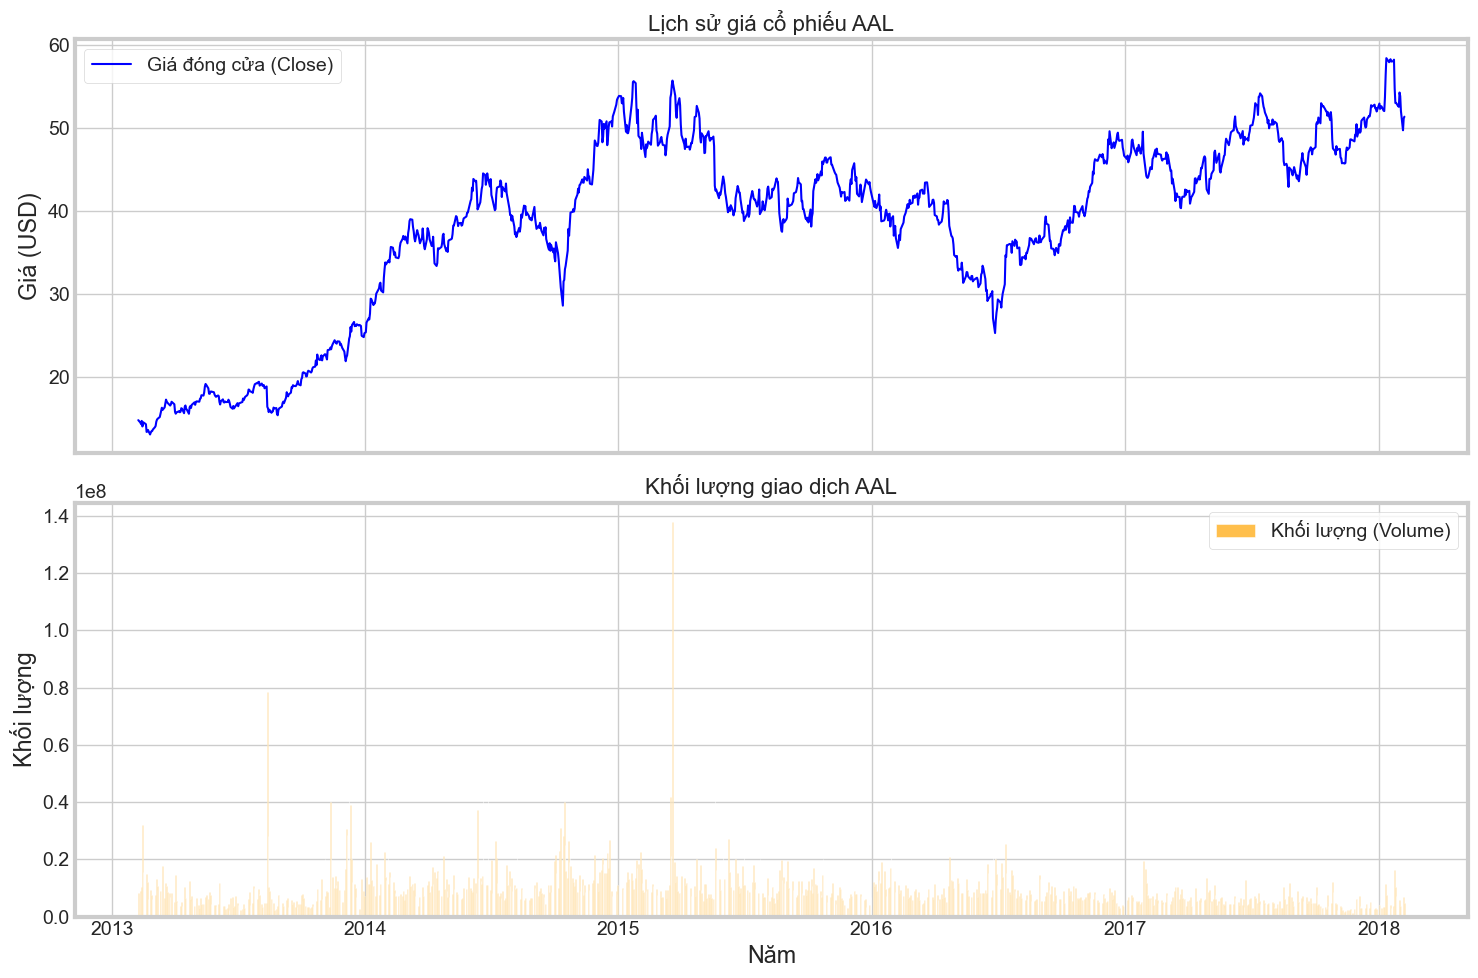

In [4]:
fig, ax = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

ax[0].plot(stock_df['close'], label='Giá đóng cửa (Close)', color='blue', linewidth=1.5)
ax[0].set_title(f'Lịch sử giá cổ phiếu {ticker}', fontsize=16)
ax[0].set_ylabel('Giá (USD)')
ax[0].legend()

ax[1].bar(stock_df.index, stock_df['volume'], label='Khối lượng (Volume)', color='orange', alpha=0.7)
ax[1].set_title(f'Khối lượng giao dịch {ticker}', fontsize=16)
ax[1].set_ylabel('Khối lượng')
ax[1].set_xlabel('Năm')
ax[1].legend()

plt.tight_layout()
plt.show()

In [5]:
stock_df = stock_df.dropna()

stock_df['Close_Lag1'] = stock_df['close'].shift(1)
stock_df['Close_Lag2'] = stock_df['close'].shift(2)
stock_df['Close_Lag3'] = stock_df['close'].shift(3)

stock_df['MA5'] = stock_df['close'].rolling(window=5).mean()
stock_df['MA20'] = stock_df['close'].rolling(window=20).mean()

stock_df.dropna(inplace=True)
stock_df[['close', 'Close_Lag1', 'Close_Lag2', 'MA5', 'MA20']].head()

,close,Close_Lag1,Close_Lag2,MA5,MA20
date,,,,,
2013-03-08,14.92,14.82,14.57,14.452,14.0075
2013-03-11,15.13,14.92,14.82,14.698,14.0265
2013-03-12,15.50,15.13,14.92,14.988,14.0785
2013-03-13,15.91,15.50,15.13,15.256,14.1605
2013-03-14,16.25,15.91,15.50,15.542,14.2400


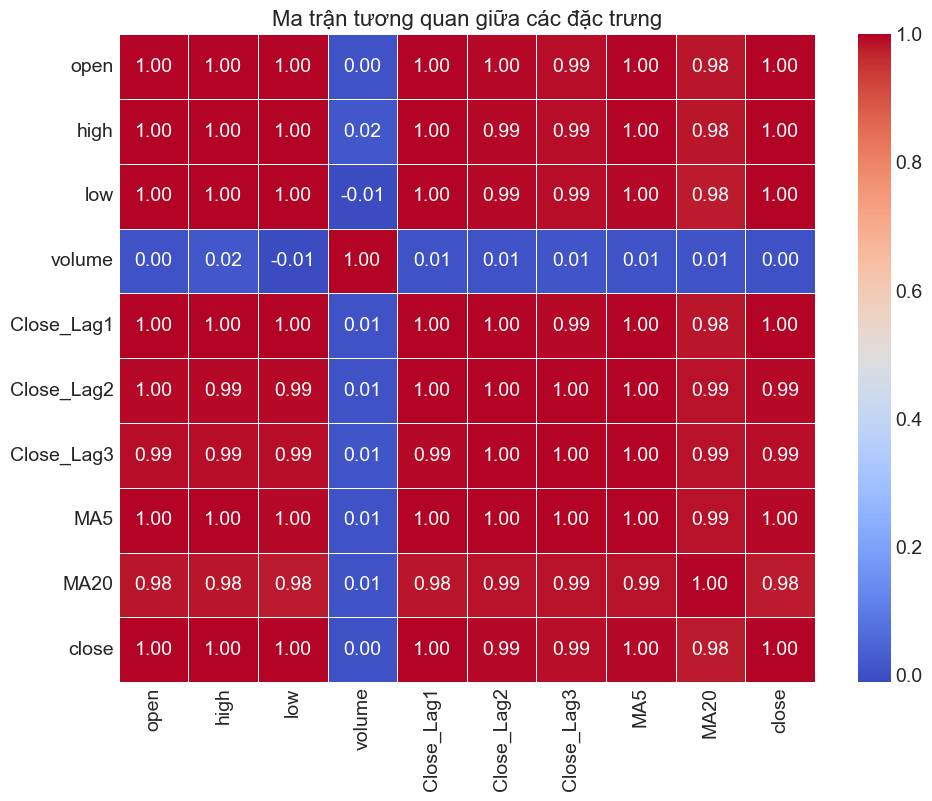

In [6]:
plt.figure(figsize=(10, 8))
features_corr = ['open', 'high', 'low', 'volume', 'Close_Lag1', 'Close_Lag2', 'Close_Lag3', 'MA5', 'MA20', 'close']
sns.heatmap(stock_df[features_corr].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Ma trận tương quan giữa các đặc trưng', fontsize=16)
plt.show()

In [7]:
features = ['open', 'high', 'low', 'volume', 'Close_Lag1', 'Close_Lag2', 'Close_Lag3', 'MA5', 'MA20']
X = stock_df[features]
y = stock_df['close']

train_size = int(len(stock_df) * 0.8)

X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test: {X_test.shape}")

Kích thước tập Train: (992, 9)
Kích thước tập Test: (248, 9)


In [8]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
print("Đang huấn luyện mô hình Random Forest...")
rf_model.fit(X_train, y_train)
print("Huấn luyện thành công!")

Đang huấn luyện mô hình Random Forest...
Huấn luyện thành công!


In [12]:
y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
accuracy = 100 - mape

print("==== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ====")
print(f"Mean Absolute Error (MAE): {mae:.4f} USD")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} USD")
print(f"R-squared Score (R2): {r2:.4f}")
print(f"Độ chính xác của mô hình (Accuracy): {accuracy:.2f}%")

==== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ====
Mean Absolute Error (MAE): 0.4544 USD
Root Mean Squared Error (RMSE): 0.6986 USD
R-squared Score (R2): 0.9667
Độ chính xác của mô hình (Accuracy): 99.08%


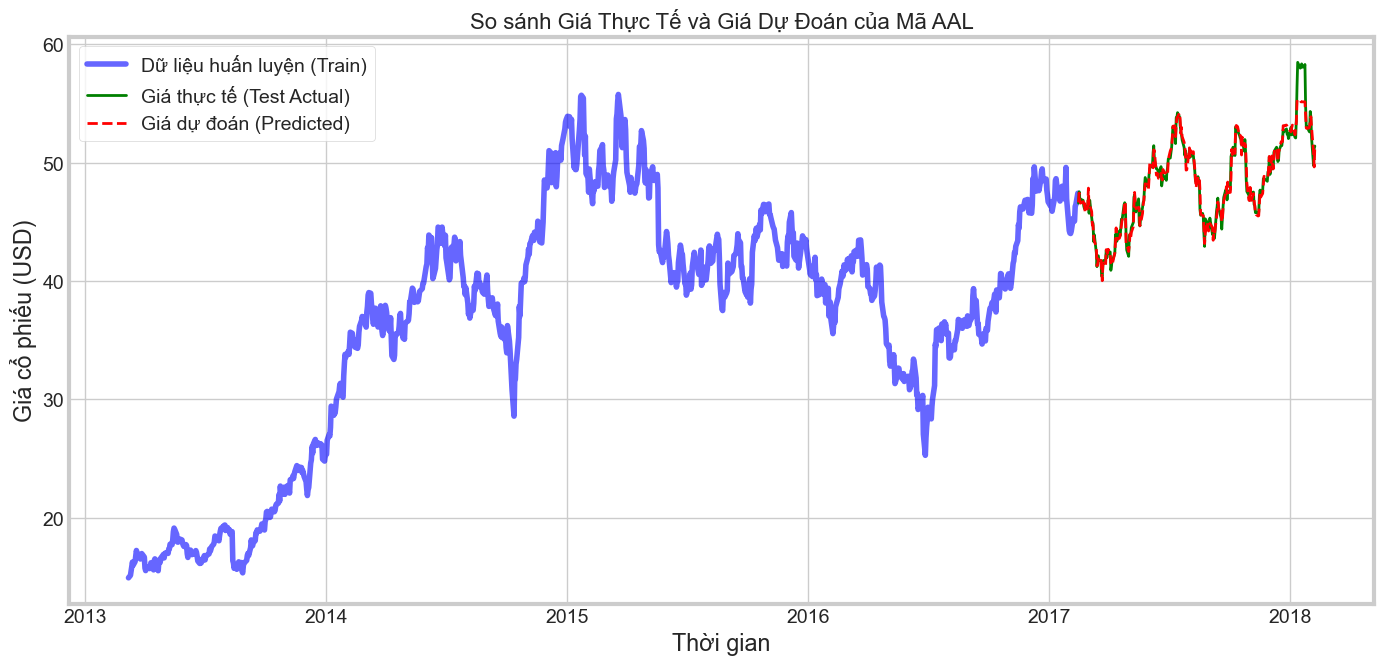

In [10]:
y_pred_series = pd.Series(y_pred, index=y_test.index)

plt.figure(figsize=(15, 7))
plt.plot(y_train, label='Dữ liệu huấn luyện (Train)', color='blue', alpha=0.6)
plt.plot(y_test, label='Giá thực tế (Test Actual)', color='green', linewidth=2)
plt.plot(y_pred_series, label='Giá dự đoán (Predicted)', color='red', linestyle='--', linewidth=2)

plt.title(f'So sánh Giá Thực Tế và Giá Dự Đoán của Mã {ticker}', fontsize=16)
plt.xlabel('Thời gian')
plt.ylabel('Giá cổ phiếu (USD)')
plt.legend(loc='upper left')
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_15620\3483460090.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=[features[i] for i in indices], palette='viridis')


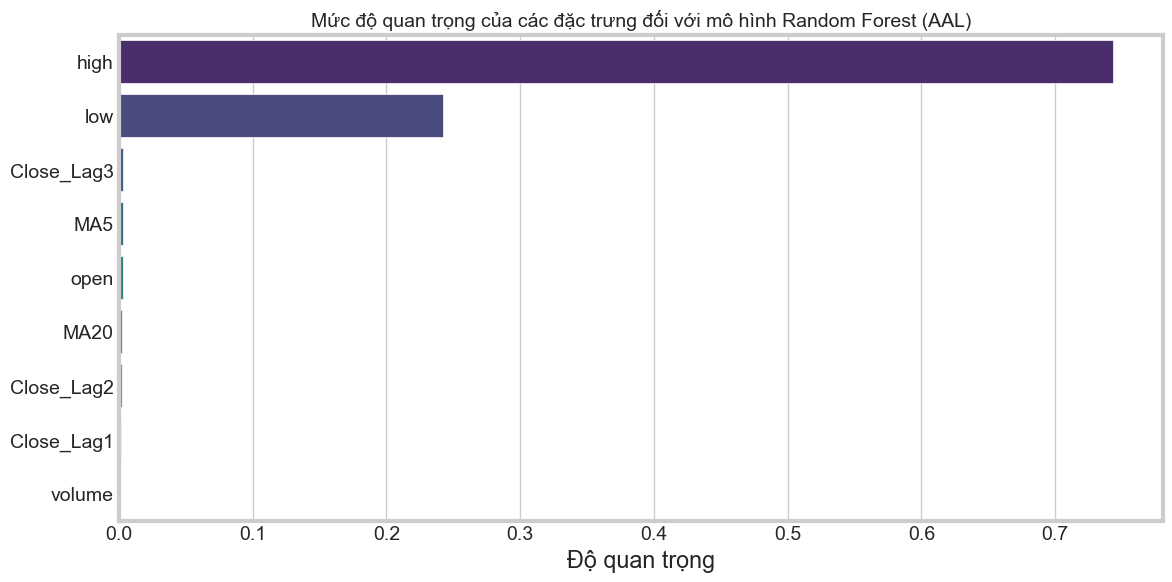

In [11]:
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title(f"Mức độ quan trọng của các đặc trưng đối với mô hình Random Forest ({ticker})", fontsize=14)
sns.barplot(x=importances[indices], y=[features[i] for i in indices], palette='viridis')
plt.xlabel('Độ quan trọng')
plt.show()